✍ В двух предыдущих юнитах мы познакомились с основными внутренними и внешними мерами, с помощью которых можно оценивать качество кластеризации. В этом юните мы попрактикуемся в решении задач кластеризации и используем полученные знания, чтобы оценить результаты.

Мы будем использовать данные, взятые с датчиков акселерометров и гироскопов смартфонов Samsung Galaxy S3. Телефоны носили в кармане добровольцы в возрасте от 19 до 49 лет. Смартфоны постоянно фиксировали значения ускорения и скорости по трём измерениям, а поведение людей записывали на видео, чтобы вручную отметить, какую физическую активность осуществлял человек в тот или иной момент.

Данные содержат следующие признаки:

- различные показатели с акселерометра и гироскопа;
- метка активности (физическая активность человека в конкретный момент).

Попробуем на основе данных с гироскопа и акселерометра разделить активности людей на некоторые схожие по своим характеристикам группы. В идеале наблюдения во время ходьбы должны попасть в один кластер, наблюдения во время подъёма по лестнице — в другой и т. д.

**Задание 4.1**

Так как изначально данные были представлены для решения задачи классификации, то они находятся в разных файлах (обучающая и тестовая выборки в соотношении 70/30). Соедините признаки так, чтобы сначала шла обучающая выборка, а затем — тестовая, и отдельно соедините значения целевых переменных (разумеется, в том же порядке).

Какая размерность получилась у набора данных с признаками?

In [86]:
import pandas as pd
import numpy as np

X_train = np.loadtxt('data/train.txt')
y_train = np.loadtxt('data/train_labels.txt')

X_test = np.loadtxt('data/test.txt')
y_test = np.loadtxt('data/test_labels.txt')

X = np.concatenate((X_train,X_test))
y = np.concatenate((y_train, y_test))

print(f'Количество объектов: {X.shape[0]:.0f}')
print(f'Количество признаков: {X.shape[1]:.0f}')

Количество объектов: 10299
Количество признаков: 561


**Задание 4.2**

Теперь найдите число различных активностей, то есть на сколько кластеров в идеале должны разделиться наблюдения.

In [88]:
len(np.unique(y))

6

Как видите, есть ряд активностей, обозначенных цифрами. Эти метки означают следующее:

- 1 — ходьба;
- 2 — подъём;
- 3 — спуск;
- 4 — сидение;
- 5 — стояние;
- 6 — лежание.

**Задание 4.3**

Далее необходимо отмасштабировать признаки. Будем использовать для этого алгоритм StandardScaler. Примените его ко всем значениям признаков и впишите в качестве ответа значение первого признака для первого объекта, предварительно округлив его до двух знаков после точки-разделителя.

In [92]:
from sklearn import preprocessing

#Инициализируем стандартизатор StandardScaler
scaler = preprocessing.StandardScaler()
#Производим стандартизацию
X_scaled = scaler.fit_transform(X)

print('значение первого признака для первого объекта:', round((X_scaled[0][0]),2))

значение первого признака для первого объекта: 0.21


**Задание 4.4**

Пора переходить к кластеризации. Для начала определите оптимальное количество кластеров, используя внутренние меры кластеризации. Используйте все известные вам коэффициенты, реализуемые в библиотеке sklearn: коэффициент силуэта, индекс Калински — Харабаса и индекс Дэвиса — Болдина. В качестве алгоритма возьмите k-means++, в качестве значения параметра random_state — число 42.

Выведите оптимальное количество кластеров для каждой метрики, перебирая значения от 2 до 9 включительно. Также введите значение каждой метрики, округлённое до двух знаков после точки-разделителя.

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_in

Количество кластеров: 2, Коэффициент силуэта: 0.39


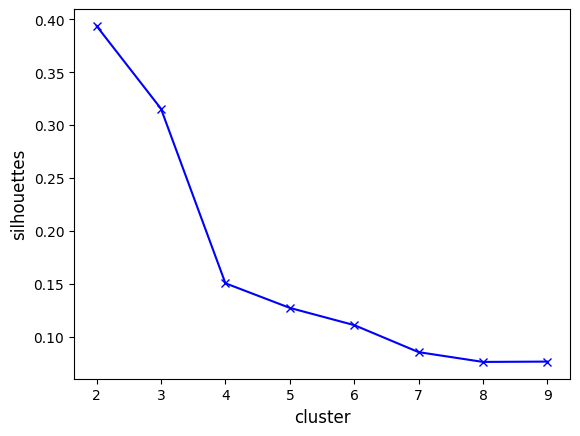

In [185]:
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#проходимся циклом по всем нужным нам значениям количества кластеров
silhouettes = {}
for i in range(2,10):
# обучаем модель k-means с текущим количеством кластеров
    km = KMeans(n_clusters = i , random_state = 42 ).fit(X_scaled)
#предсказываем метки
    y_pred = km.labels_
    # Добавляем значение в словарь
    silhouettes[i] =  metrics.silhouette_score(X_scaled,  y_pred)
#выводим результат для коэффициента силуэта
    #print (i, metrics.silhouette_score(X_scaled,  y_pred))

keys = silhouettes.keys()
values = silhouettes.values()
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouettes", fontsize=12)
plt.plot(keys, values, 'xb-');
print(f'Количество кластеров: 2, Коэффициент силуэта: {silhouettes[2]:.2f}')

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_in

Количество кластеров: 2, Индекс Калински — Харабаса: 7880.81


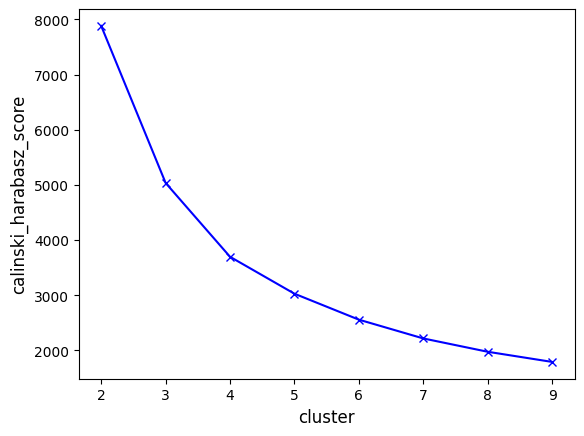

In [186]:
from sklearn.metrics import calinski_harabasz_score

#проходимся циклом по всем нужным нам значениям количества кластеров
calinski_harabasz_score = {}
for i in range(2,10):
# обучаем модель k-means с текущим количеством кластеров
    km = KMeans(n_clusters = i , random_state = 42 ).fit(X_scaled)
#предсказываем метки
    y_pred = km.labels_
    # Добавляем значение в словарь
    calinski_harabasz_score[i] =  metrics.calinski_harabasz_score(X_scaled,  y_pred)

# Начертим график зависимости calinski_harabasz_score от кол-ва кластеров  
keys = calinski_harabasz_score.keys()
values = calinski_harabasz_score.values()
plt.xlabel("cluster", fontsize=12)
plt.ylabel("calinski_harabasz_score", fontsize=12)
plt.plot(keys, values, 'xb-');
print(f'Количество кластеров: 2, Индекс Калински — Харабаса: {calinski_harabasz_score[2]:.2f}')

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_in

Количество кластеров: 2, Индекс Дэвиса — Болдина: 1.07


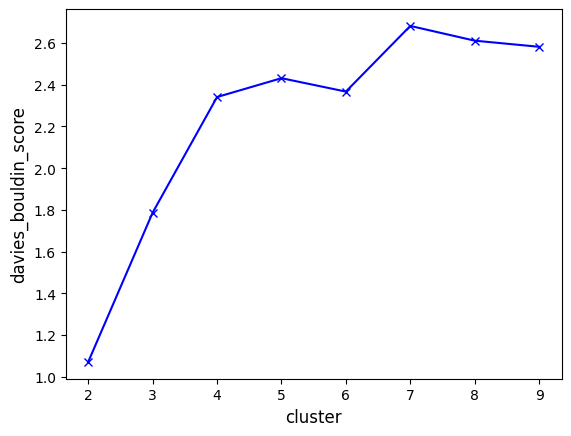

In [187]:
from sklearn.metrics import davies_bouldin_score

#проходимся циклом по всем нужным нам значениям количества кластеров
davies_bouldin_score = {}
for i in range(2,10):
# обучаем модель k-means с текущим количеством кластеров
    km = KMeans(n_clusters = i , random_state = 42 ).fit(X_scaled)
#предсказываем метки
    y_pred = km.labels_
    # Добавляем значение в словарь
    davies_bouldin_score[i] =  metrics.davies_bouldin_score(X_scaled,  y_pred)

# Начертим график зависимости calinski_harabasz_score от кол-ва кластеров  
keys = davies_bouldin_score.keys()
values = davies_bouldin_score.values()
plt.xlabel("cluster", fontsize=12)
plt.ylabel("davies_bouldin_score", fontsize=12)
plt.plot(keys, values, 'xb-');
print(f'Количество кластеров: 2, Индекс Дэвиса — Болдина: {davies_bouldin_score[2]:.2f}')

**Задание 4.5**

Теперь давайте оценим качество кластеризации с точки зрения внешних мер. Реализуйте кластеризацию с помощью классической версии алгоритма k-means. Пусть количество кластеров будет соответствовать количеству активностей. Задайте следующие значения параметров: random_state=42, init='random'.

В качестве ответов введите значения получившихся мер, предварительно округлив их до двух знаков после точки-разделителя.

In [132]:
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics.cluster import adjusted_rand_score

# обучаем модель k-means с текущим количеством кластеров
km = KMeans(n_clusters = len(np.unique(y)) , random_state = 42, init='random').fit(X_scaled)
#предсказываем метки
y_pred = km.labels_

print(f'Однородность:: {homogeneity_score(y, y_pred):.2f}')
print(f'Полнота:: {completeness_score(y, y_pred):.2f}')
print(f'ARI (скорректированный индекс Рэнда): {adjusted_rand_score(y, y_pred):.2f}')

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Однородность:: 0.54
Полнота:: 0.58
ARI (скорректированный индекс Рэнда): 0.42


**Задание 4.6**

Выясните, к каким кластерам были преимущественно отнесены различные активности (т. е. в какой кластер попало большинство наблюдений с этой активностью). Нумерацию кластеров начинайте с 1.

In [183]:
#создаём таблицу сопряжённости
ct = pd.crosstab(y, km.labels_)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,7))
ct

,1,2,3,4,5,6
ходьба,0,0,903,78,741,0
подъём,0,0,1242,5,295,2
спуск,0,0,321,196,889,0
сидение,91,1238,1,0,0,447
стояние,0,1346,0,0,0,560
лежание,1556,54,5,0,0,329


**Задание 4.7**

Теперь попробуйте реализовать алгоритм k-means для двух кластеров (для того числа активностей, которое является оптимальным с точки зрения внутренних мер) и снова посмотреть, как алгоритм разобьёт активности по кластерам. Как и в предыдущем задании, нумерацию кластеров начинайте с 1.

In [188]:
# обучаем модель k-means с текущим количеством кластеров
km = KMeans(n_clusters = 2 , random_state = 42, init='random').fit(X_scaled)

#создаём таблицу сопряжённости
ct = pd.crosstab(y, km.labels_)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,3))
ct

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,1,2
ходьба,1722,0
подъём,1536,8
спуск,1406,0
сидение,3,1774
стояние,0,1906
лежание,12,1932


<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Теперь вы видите, что разбиение на два кластера, которое нам навязчиво предлагали внутренние меры, вполне разумно, так как отражает два принципиально разных класса активностей: <b>неподвижные</b> и <b>подвижные</b>.

**Задание 4.8**

Вычислите значение полноты для разбиения на два кластера алгоритмом k-means. Ответ округлите до двух знаков после точки-разделителя.

In [189]:
print(f'Полнота: {completeness_score(y, km.labels_):.2f}')

Полнота: 0.98


**Задание 4.9**

Как можно интерпретировать полученное значение полноты?

- A С точки зрения полноты разбиение получилось менее качественным, чем для шести кластеров.
- **B** С точки зрения полноты разбиение получилось более качественным, чем для шести кластеров.
- C В каждом кластере преимущественно находятся метки только одного класса.
- **D** Метки одного класса преимущественно находятся в одних и тех же кластерах.

**Задание 4.10**

Давайте сравним полученный результат с агломеративной иерархической кластеризацией. Реализуйте её также для двух кластеров и вычислите значение полноты.

1. Какой алгоритм показывает наилучшее качество, если судить по полноте?

*Агломеративная кластеризация*

In [192]:
from sklearn.cluster import AgglomerativeClustering

# обучаем модель с текущим количеством кластеров
clustering = AgglomerativeClustering(n_clusters=2).fit(X_scaled)

#предсказываем метки
y_pred = clustering.labels_

print(f'Полнота: {completeness_score(y, y_pred):.2f}')

Полнота: 1.00
